# QLoRA Fine-Tuning: Qwen2.5-3B-Instruct on Customer Support Dataset
**Target hardware:** Google Colab Free Tier — T4 GPU (≈15 GB VRAM)  
**Method:** QLoRA (4-bit quantisation + LoRA r=8)  
**Dataset:** `bitext/Bitext-customer-support-llm-chatbot-training-dataset` (26,872 samples → 6,000 used)  
**Goal:** Light domain adaptation — expose the model to customer-support style without overfitting.

Pipeline:
1. Install dependencies (Colab)
2. Mount Drive & load config
3. Accelerate + MLflow setup
4. Dataset load & preprocessing
5. 4-bit model load + LoRA
6. **Pre-training evaluation** (perplexity + generation)
7. Training with 8-bit AdamW
8. **Post-training evaluation** (perplexity + generation)
9. Save adapter & merge

## 1. Install Dependencies (Colab)

In [1]:
# Run once on Colab
!pip install -q transformers>=4.45.0 peft>=0.12.0 accelerate>=0.34.0 bitsandbytes>=0.43.0 datasets>=2.20.0 mlflow>=2.14.0 dagshub pyyaml tqdm scipy

print("All packages installed.")

All packages installed.


## 2. Load Config

In [2]:
import os, yaml

# ── Load config ───────────────────────────────────────────────────────
# Place finetune_config.yaml in your Colab working directory or adjust the path
CONFIG_PATH = "finetune_config.yaml"

with open(CONFIG_PATH) as f:
    CFG = yaml.safe_load(f)

print("Config loaded:")
print(f"  Model           : {CFG['model']['name']}")
print(f"  Max seq length  : {CFG['model']['max_seq_length']}")
print(f"  Train samples   : {CFG['dataset']['train_samples']}")
print(f"  Val samples     : {CFG['dataset']['val_samples']}")
print(f"  Epochs          : {CFG['training']['num_epochs']}")
print(f"  LoRA r          : {CFG['lora']['r']}")
print(f"  Optimizer       : {CFG['training']['optim']}")
print(f"  Output dir      : {CFG['checkpointing']['output_dir']}")

Config loaded:
  Model           : Qwen/Qwen2.5-3B-Instruct
  Max seq length  : 512
  Train samples   : 6000
  Val samples     : 600
  Epochs          : 1
  LoRA r          : 8
  Optimizer       : adamw_bnb_8bit
  Output dir      : /content/qlora_qwen_customer_support


## 3. Imports & Reproducibility

In [3]:
import gc, math, json, random, warnings
from pathlib import Path

import torch
import numpy as np
import mlflow
from tqdm.auto import tqdm

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig,
    get_cosine_schedule_with_warmup,
)
from peft import (
    LoraConfig,
    get_peft_model,
    TaskType,
    prepare_model_for_kbit_training,
    PeftModel,
)
from torch.utils.data import DataLoader
from accelerate import Accelerator
from accelerate.utils import find_executable_batch_size, set_seed
import bitsandbytes as bnb

warnings.filterwarnings('ignore')

SEED = CFG['dataset']['seed']
set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f'PyTorch   : {torch.__version__}')
print(f'CUDA avail: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU       : {torch.cuda.get_device_name(0)}')
    print(f'VRAM total: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

PyTorch   : 2.10.0+cu128
CUDA avail: True
GPU       : Tesla T4
VRAM total: 15.6 GB


## 4. Accelerate + MLflow Setup

In [4]:
import dagshub

# ── DagsHub authentication ────────────────────────────────────────────
# dagshub.init() sets MLFLOW_TRACKING_URI, MLFLOW_TRACKING_USERNAME,
# and MLFLOW_TRACKING_PASSWORD automatically using your DagsHub token.
# It will prompt for your token on first run (stored in ~/.dagshub/token).
dagshub.init(
    repo_owner=CFG['mlflow']['dagshub_username'],
    repo_name=CFG['mlflow']['dagshub_repo'],
    mlflow=True,   # sets MLFLOW_TRACKING_URI to the DagsHub endpoint
)

# Confirm the tracking URI was set by dagshub.init()
import mlflow
print(f'MLflow tracking URI : {mlflow.get_tracking_uri()}')

mlflow.set_experiment(CFG['mlflow']['experiment_name'])

# ── Accelerate with MLflow tracker ────────────────────────────────────
accelerator = Accelerator(
    gradient_accumulation_steps=CFG['training']['gradient_accumulation_steps'],
    mixed_precision='bf16',
    log_with='mlflow',
    project_dir=CFG['checkpointing']['output_dir'],
)

flat_cfg = {
    'model':         CFG['model']['name'],
    'max_seq_len':   CFG['model']['max_seq_length'],
    'train_samples': CFG['dataset']['train_samples'],
    'num_epochs':    CFG['training']['num_epochs'],
    'lr':            CFG['training']['learning_rate'],
    'lora_r':        CFG['lora']['r'],
    'lora_alpha':    CFG['lora']['lora_alpha'],
    'lora_target':   ','.join(CFG['lora']['target_modules']),
    'optim':         CFG['training']['optim'],
    'grad_accum':    CFG['training']['gradient_accumulation_steps'],
    'quant_type':    CFG['quantization']['bnb_4bit_quant_type'],
}

accelerator.init_trackers(
    project_name=CFG['mlflow']['experiment_name'],
    config=flat_cfg,
    init_kwargs={'mlflow': {'run_name': CFG['mlflow']['run_name']}},
)

print(f'Accelerator device  : {accelerator.device}')
print(f'Mixed precision     : {accelerator.mixed_precision}')
print(f'DagsHub experiment  : {CFG["mlflow"]["experiment_name"]}')
print(f'DagsHub run name    : {CFG["mlflow"]["run_name"]}')

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=6a09feef-8abf-4adb-92f0-cc06fce4c088&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=03223eabd9ae8531012104821131462735f5f93a8ac153e8150e0d15e5a81c6c




Output()

Accessing as nemroneno2526

Initialized MLflow to track repo "nemroneno2526/LLM_project"

Repository nemroneno2526/LLM_project initialized!

MLflow tracking URI : https://dagshub.com/nemroneno2526/LLM_project.mlflow
Accelerator device  : cuda
Mixed precision     : bf16
DagsHub experiment  : qwen25_3b_qlora_banking_conversation
DagsHub run name    : qlora_r8_1epoch_6k


## 5. Load Tokenizer

In [5]:
MODEL_NAME  = CFG['model']['name']
MAX_SEQ_LEN = CFG['model']['max_seq_length']

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
tokenizer.padding_side = 'right'   # Required for causal LM training

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print(f'Vocab size  : {tokenizer.vocab_size:,}')
print(f'EOS token   : {tokenizer.eos_token!r}  (id={tokenizer.eos_token_id})')
print(f'PAD token   : {tokenizer.pad_token!r}  (id={tokenizer.pad_token_id})')
print(f'Max seq len : {MAX_SEQ_LEN}')

config.json:   0%|          | 0.00/661 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Vocab size  : 151,643
EOS token   : '<|im_end|>'  (id=151645)
PAD token   : '<|endoftext|>'  (id=151643)
Max seq len : 512


## 6. Load & Preprocess Dataset (Stratified Split)
Splitting is **stratified on ** (27 classes) so every intent is represented at the same proportion in both train and val — guaranteeing no distribution mismatch for fair benchmarking.

In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split as sk_split
from datasets import Dataset

SYSTEM_MSG = CFG['prompt']['system']
TRAIN_N    = CFG['dataset']['train_samples']
VAL_N      = CFG['dataset']['val_samples']
TOTAL_N    = TRAIN_N + VAL_N

def format_prompt(instruction: str, response: str) -> str:
    """ChatML format matching Qwen2.5-Instruct native chat template."""
    return (
        f'<|im_start|>system\n{SYSTEM_MSG}<|im_end|>\n'
        f'<|im_start|>user\n{instruction}<|im_end|>\n'
        f'<|im_start|>assistant\n{response}<|im_end|>'
    )

print('Loading dataset from HuggingFace...')
raw     = load_dataset(CFG['dataset']['name'], split='train')
full_df = raw.to_pandas()

# Drop duplicate instructions before splitting to prevent train/val leakage
full_df = full_df.drop_duplicates(subset=['instruction']).reset_index(drop=True)

print(f'Full dataset : {len(full_df):,} rows | '
      f'{full_df["category"].nunique()} categories | '
      f'{full_df["intent"].nunique()} intents')

# ── Step 1: Carve out a stratified pool of TOTAL_N from the full dataset ──
# Stratifying on intent (27 classes) guarantees each intent keeps its
# original proportion in the subset.
_, pool_df = sk_split(
    full_df,
    test_size=TOTAL_N / len(full_df),
    stratify=full_df['intent'],
    random_state=SEED,
)

# ── Step 2: Split pool into train / val, again stratified on intent ────────
train_df, val_df = sk_split(
    pool_df,
    test_size=VAL_N / TOTAL_N,
    stratify=pool_df['intent'],
    random_state=SEED,
)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)

print(f'Train subset : {len(train_df):,}')
print(f'Val subset   : {len(val_df):,}')

# ── Overlap check ──────────────────────────────────────────────────────────
# Original indices from full_df are preserved until reset_index;
# We check before the reset using pool indices.
# Verify no overlap by checking instruction text (ground-truth check).
train_instructions = set(train_df['instruction'].tolist())
val_instructions   = set(val_df['instruction'].tolist())
overlap_count = len(train_instructions & val_instructions)
print(f'Instruction text overlap : {overlap_count} rows')
assert overlap_count == 0, f'OVERLAP DETECTED: {overlap_count} shared instructions!'
print('Overlap check            : PASSED')

# ── Distribution comparison ─────────────────────────────────────────────────
print('Intent distribution comparison (train vs val)  [should be near-identical]:')
train_intent_pct = train_df['intent'].value_counts(normalize=True).rename('train_%')
val_intent_pct   = val_df['intent'].value_counts(normalize=True).rename('val_%')
dist_df = pd.concat([train_intent_pct, val_intent_pct], axis=1).round(4)
dist_df['drift'] = (dist_df['train_%'] - dist_df['val_%']).abs().round(4)
print(dist_df.sort_values('drift', ascending=False).to_string())

max_drift = dist_df['drift'].max()
print(f'Max intent proportion drift : {max_drift:.4f}  (< 0.01 = well-balanced)')

print('Category distribution comparison (train vs val):')
train_cat_pct = train_df['category'].value_counts(normalize=True).rename('train_%')
val_cat_pct   = val_df['category'].value_counts(normalize=True).rename('val_%')
cat_df = pd.concat([train_cat_pct, val_cat_pct], axis=1).round(4)
cat_df['drift'] = (cat_df['train_%'] - cat_df['val_%']).abs().round(4)
print(cat_df.to_string())

# ── Convert back to HuggingFace Dataset for tokenisation ───────────────────
train_hf = Dataset.from_pandas(train_df)
val_hf   = Dataset.from_pandas(val_df)

def tokenise(example):
    text = format_prompt(example['instruction'], example['response'])
    enc  = tokenizer(
        text,
        max_length=MAX_SEQ_LEN,
        truncation=True,
        # REMOVED padding='max_length' to use Dynamic Padding instead!
    )
    # The collator will automatically pad to the longest sequence in the batch.
    enc['labels'] = enc['input_ids'].copy()
    return enc

print('Tokenising train set...')
train_tok = train_hf.map(tokenise, remove_columns=train_hf.column_names, num_proc=2)
print('Tokenising val set...')
val_tok   = val_hf.map(tokenise,   remove_columns=val_hf.column_names,   num_proc=2)

# Do not pad during tokenisation. We defer this to the dataloader!
# train_tok.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])
# val_tok.set_format(type='torch',   columns=['input_ids', 'attention_mask', 'labels'])

print('Tokenisation complete.')
print(f'Train tok size : {len(train_tok):,}')
print(f'Val tok size   : {len(val_tok):,}')


Loading dataset from HuggingFace...


README.md: 0.00B [00:00, ?B/s]

Bitext_Sample_Customer_Support_Training_(…):   0%|          | 0.00/19.2M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/26872 [00:00<?, ? examples/s]

Full dataset : 24,635 rows | 11 categories | 27 intents
Train subset : 6,000
Val subset   : 601
Instruction text overlap : 0 rows
Overlap check            : PASSED
Intent distribution comparison (train vs val)  [should be near-identical]:
                          train_%   val_%   drift
intent                                           
payment_issue              0.0405  0.0416  0.0011
delivery_period            0.0405  0.0416  0.0011
registration_problems      0.0405  0.0416  0.0011
contact_customer_service   0.0405  0.0416  0.0011
complaint                  0.0405  0.0416  0.0011
check_invoice              0.0373  0.0383  0.0010
newsletter_subscription    0.0407  0.0399  0.0008
check_payment_methods      0.0407  0.0399  0.0008
contact_human_agent        0.0407  0.0399  0.0008
get_refund                 0.0373  0.0366  0.0007
delete_account             0.0373  0.0366  0.0007
review                     0.0405  0.0399  0.0006
recover_password           0.0405  0.0399  0.0006
check_refun

Map (num_proc=2):   0%|          | 0/6000 [00:00<?, ? examples/s]

Tokenising val set...


Map (num_proc=2):   0%|          | 0/601 [00:00<?, ? examples/s]

Tokenisation complete.
Train tok size : 6,000
Val tok size   : 601


## 7. DataLoaders
`find_executable_batch_size` will automatically halve the batch size and retry if a CUDA OOM is encountered during training.

In [7]:
from transformers import DataCollatorForSeq2Seq

# Overriding the config batch size to maximize T4 GPU utilization
STARTING_BATCH = 16
EVAL_BATCH     = CFG['training']['per_device_eval_batch_size']
NUM_WORKERS    = CFG['training']['dataloader_num_workers']

# Dynamic Padding Collator: Only pads to the max length *in the current batch*
# rather than exactly 512 for every single batch
collator = DataCollatorForSeq2Seq(
    tokenizer,
    pad_to_multiple_of=8,
    return_tensors="pt",
    padding=True
)

def make_dataloaders(batch_size: int):
    train_loader = DataLoader(
        train_tok, batch_size=batch_size,
        shuffle=True, num_workers=NUM_WORKERS, pin_memory=True, collate_fn=collator
    )
    val_loader = DataLoader(
        val_tok, batch_size=EVAL_BATCH,
        shuffle=False, num_workers=NUM_WORKERS, pin_memory=True, collate_fn=collator
    )
    return train_loader, val_loader

print(f'DataLoaders ready (starting batch size = {STARTING_BATCH} per device, dynamic padding enabled).')

DataLoaders ready (starting batch size = 16 per device, dynamic padding enabled).


## 8. Load Base Model in 4-bit

In [8]:
bnb_config = BitsAndBytesConfig(
    load_in_4bit=CFG['quantization']['load_in_4bit'],
    bnb_4bit_quant_type=CFG['quantization']['bnb_4bit_quant_type'],
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=CFG['quantization']['bnb_4bit_use_double_quant'],
)

print(f'Loading {MODEL_NAME} in 4-bit NF4...')
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map='auto',          # BitsAndBytes places layers on available GPU/CPU
    trust_remote_code=True,
    torch_dtype=torch.bfloat16,
)

# Prepare for k-bit training: disables non-trainable param grad computation
model = prepare_model_for_kbit_training(
    model,
    use_gradient_checkpointing=CFG['training']['gradient_checkpointing'],
)

total_params = sum(p.numel() for p in model.parameters())
print(f'Base model params : {total_params/1e9:.2f} B')
if torch.cuda.is_available():
    used = torch.cuda.memory_allocated() / 1e9
    total = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'VRAM after model load: {used:.2f} / {total:.1f} GB')

Loading Qwen/Qwen2.5-3B-Instruct in 4-bit NF4...


`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Base model params : 1.70 B
VRAM after model load: 2.69 / 15.6 GB


## 9. Apply LoRA Adapter (PEFT)

In [9]:
lora_cfg = LoraConfig(
    r=CFG['lora']['r'],
    lora_alpha=CFG['lora']['lora_alpha'],
    target_modules=CFG['lora']['target_modules'],   # q_proj + v_proj only
    lora_dropout=CFG['lora']['lora_dropout'],
    bias=CFG['lora']['bias'],
    task_type=TaskType.CAUSAL_LM,
)

model = get_peft_model(model, lora_cfg)
model.print_trainable_parameters()

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'Trainable: {trainable/1e6:.2f} M  |  Total: {total/1e9:.2f} B  |  {100*trainable/total:.3f}%')

trainable params: 1,843,200 || all params: 3,087,781,888 || trainable%: 0.0597
Trainable: 1.84 M  |  Total: 1.70 B  |  0.108%


## 10. Evaluation Helpers
- **Perplexity**: mean cross-entropy loss → `exp(loss)` over the validation set. Lower is better.
- **Generation**: qualitative responses for fixed prompts — compared before vs after training.

In [10]:
@torch.no_grad()
def compute_perplexity(mdl, loader, accel, max_batches=None):
    mdl.eval()
    total_loss, n = 0.0, 0
    for i, batch in enumerate(tqdm(loader, desc='Perplexity', leave=False)):
        if max_batches and i >= max_batches:
            break
        out  = mdl(input_ids=batch['input_ids'],
                   attention_mask=batch['attention_mask'],
                   labels=batch['labels'])
        loss = accel.gather(out.loss).mean()
        total_loss += loss.item()
        n += 1
    return math.exp(total_loss / max(n, 1))

@torch.no_grad()
def generate_samples(mdl, tok, prompts, max_new_tokens=200):
    mdl.eval()
    results = []
    for instruction in prompts:
        prompt_text = (
            f'<|im_start|>system\n{SYSTEM_MSG}<|im_end|>\n'
            f'<|im_start|>user\n{instruction}<|im_end|>\n'
            f'<|im_start|>assistant\n'
        )
        inputs = tok(prompt_text, return_tensors='pt').to(accelerator.device)
        out = mdl.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=CFG.get('inference', {}).get('temperature', 0.2),
            repetition_penalty=CFG.get('inference', {}).get('repetition_penalty', 1.05),
            do_sample=False,
            pad_token_id=tok.pad_token_id,
            eos_token_id=tok.eos_token_id,
        )
        gen_ids = out[0][inputs['input_ids'].shape[1]:]
        results.append(tok.decode(gen_ids, skip_special_tokens=True).strip())
    return results

# Fixed evaluation prompts drawn from dataset categories
EVAL_PROMPTS = [
    'I need to cancel my order {{Order Number}}, how do I do that?',
    'What payment methods do you accept?',
    'My delivery is late, can you help me track it?',
    'How do I update my account email address?',
    'I was charged twice for my purchase, I want a refund.',
]
print(f'Evaluation helpers ready. Fixed prompts: {len(EVAL_PROMPTS)}')

Evaluation helpers ready. Fixed prompts: 5


## 11. Pre-Training Evaluation (Baseline)

In [11]:
PPL_N     = CFG['dataset']['eval_ppl_samples']
ppl_tok   = val_tok.select(range(min(PPL_N, len(val_tok))))
ppl_tok.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])

# Adding the collator here so the pre-training evaluation handles dynamic padding!
ppl_loader = DataLoader(ppl_tok, batch_size=EVAL_BATCH, shuffle=False, collate_fn=collator)
ppl_loader = accelerator.prepare(ppl_loader)

print('=' * 50)
print('PRE-TRAINING EVALUATION')
print('=' * 50)

pre_ppl = compute_perplexity(model, ppl_loader, accelerator)
print(f'Baseline perplexity : {pre_ppl:.4f}')

print('\n--- Baseline generations ---')
pre_generations = generate_samples(model, tokenizer, EVAL_PROMPTS)
for prompt, gen in zip(EVAL_PROMPTS, pre_generations):
    print(f'\nQ: {prompt}')
    print(f'A: {gen[:300]}')

accelerator.log({'eval/pre_perplexity': pre_ppl}, step=0)
print('\nBaseline perplexity logged to MLflow.')

PRE-TRAINING EVALUATION


Perplexity:   0%|          | 0/75 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Baseline perplexity : 24.6757

--- Baseline generations ---

Q: I need to cancel my order {{Order Number}}, how do I do that?
A: To cancel your order with the order number {{Order Number}}, you should follow these steps:

1. Log in to your account on the website or app where you placed the order.
2. Navigate to the "My Orders" or "Order History" section.
3. Locate your order by filtering by order number or date, then click on

Q: What payment methods do you accept?
A: The payment methods we accept depend on the specific service or product you're purchasing. However, some common options include credit cards, debit cards, PayPal, and bank transfers. Please check the checkout page for the available options.

Q: My delivery is late, can you help me track it?
A: I'm sorry to hear that your delivery is delayed. To help you track your package, I would need more information such as the tracking number or the order ID. Could you please provide that?

Q: How do I update my account email address?

## 12. 8-bit AdamW Optimizer & Cosine LR Scheduler
**bitsandbytes AdamW 8-bit** keeps optimizer states in 8-bit precision, cutting optimizer VRAM by ~50% vs fp32 AdamW — crucial for free-tier T4.

In [12]:
LR           = CFG['training']['learning_rate']
WEIGHT_DECAY = CFG['training']['weight_decay']
WARMUP_RATIO = CFG['training']['warmup_ratio']
NUM_EPOCHS   = CFG['training']['num_epochs']

# Drop gradient accumulation so we actually speed up the epoch and fully utilize parallel processing!
# Keeping the effective batch size around 16.
GRAD_ACCUM   = max(1, 16 // STARTING_BATCH)

optimizer = bnb.optim.AdamW8bit(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR,
    weight_decay=WEIGHT_DECAY,
    betas=(0.9, 0.95),
)
print(f'Optimizer : bitsandbytes AdamW 8-bit | lr={LR} | wd={WEIGHT_DECAY}')

# Estimate total steps at starting batch size
_steps_per_epoch = math.ceil(TRAIN_N / (STARTING_BATCH * GRAD_ACCUM))
_total_steps     = _steps_per_epoch * NUM_EPOCHS
_warmup_steps    = max(1, int(_total_steps * WARMUP_RATIO))

scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=_warmup_steps,
    num_training_steps=_total_steps,
)
print(f'Scheduler : cosine with {_warmup_steps} warmup steps / {_total_steps} total steps')

Optimizer : bitsandbytes AdamW 8-bit | lr=0.0002 | wd=0.01
Scheduler : cosine with 18 warmup steps / 375 total steps


## 13. Training Loop

Key design points:
- `@find_executable_batch_size` — halves batch size automatically on OOM and retries.
- `accelerator.prepare()` — wraps model, optimizer, dataloaders, scheduler for device placement & mixed precision.
- `accelerator.accumulate(model)` — handles gradient accumulation context; `optimizer.step()` is skipped on non-sync steps.
- `accelerator.backward(loss)` — applies loss scaling for bf16.
- `accelerator.save_state()` — saves model + optimizer + scheduler state (full resumable checkpoint).
- `accelerator.log()` — pipes all metrics to the MLflow run.

In [13]:
LOG_STEPS  = CFG['checkpointing']['logging_steps']
EVAL_STEPS = CFG['checkpointing']['eval_steps']
SAVE_STEPS = CFG['checkpointing']['save_steps']
MAX_GRAD   = CFG['training']['max_grad_norm']
OUTPUT_DIR = CFG['checkpointing']['output_dir']
Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

@find_executable_batch_size(starting_batch_size=STARTING_BATCH)
def run_training(batch_size: int):
    global optimizer, scheduler

    print(f'>>> Training with batch_size={batch_size} per device  '
          f'(effective={batch_size * GRAD_ACCUM})')

    train_loader, val_loader = make_dataloaders(batch_size)

    # prepare() handles device placement + mixed-precision wrapping
    (
        model_p, optimizer_p,
        train_loader_p, val_loader_p,
        scheduler_p
    ) = accelerator.prepare(
        model, optimizer, train_loader, val_loader, scheduler
    )

    global_step   = 0
    best_val_ppl  = float('inf')
    loss_history  = []

    for epoch in range(NUM_EPOCHS):
        model_p.train()
        epoch_loss_sum = 0.0
        pbar = tqdm(train_loader_p, desc=f'Epoch {epoch+1}/{NUM_EPOCHS}')

        for batch in pbar:
            with accelerator.accumulate(model_p):
                outputs = model_p(
                    input_ids=batch['input_ids'],
                    attention_mask=batch['attention_mask'],
                    labels=batch['labels'],
                )
                loss = outputs.loss
                # Accelerate handles bf16 loss scaling
                accelerator.backward(loss)

                if accelerator.sync_gradients:
                    accelerator.clip_grad_norm_(model_p.parameters(), MAX_GRAD)

                optimizer_p.step()
                scheduler_p.step()
                optimizer_p.zero_grad()

            if accelerator.sync_gradients:
                global_step    += 1
                loss_val        = loss.detach().float().item()
                epoch_loss_sum += loss_val
                loss_history.append(loss_val)
                lr_now          = scheduler_p.get_last_lr()[0]
                pbar.set_postfix({'loss': f'{loss_val:.4f}', 'lr': f'{lr_now:.2e}'})

                # ── Log to MLflow ──────────────────────────────────────
                if global_step % LOG_STEPS == 0:
                    accelerator.log(
                        {'train/loss': loss_val, 'train/lr': lr_now},
                        step=global_step,
                    )

                # ── Validation perplexity ──────────────────────────────
                if global_step % EVAL_STEPS == 0:
                    val_ppl = compute_perplexity(model_p, val_loader_p, accelerator)
                    accelerator.log({'eval/perplexity': val_ppl}, step=global_step)
                    print(f'  [step {global_step}] val_ppl={val_ppl:.4f}')

                    if val_ppl < best_val_ppl:
                        best_val_ppl = val_ppl
                        # Unbind model to save purely the lightweight PEFT LoRA adapter (15MB)
                        # Instead of the massive 4-bit base model (which causes massive freeze & sharding bugs!)
                        unwrapped_model = accelerator.unwrap_model(model_p)
                        unwrapped_model.save_pretrained(os.path.join(OUTPUT_DIR, 'best_checkpoint'), safe_serialization=True)
                        print(f'  [step {global_step}] Best checkpoint saved (ppl={val_ppl:.4f})')
                    model_p.train()

                # ── Periodic checkpoint ────────────────────────────────
                if global_step % SAVE_STEPS == 0:
                    unwrapped_model = accelerator.unwrap_model(model_p)
                    unwrapped_model.save_pretrained(os.path.join(OUTPUT_DIR, f'checkpoint-{global_step}'), safe_serialization=True)

        avg_loss = epoch_loss_sum / max(len(train_loader_p), 1)
        print(f'Epoch {epoch+1} done | avg_loss={avg_loss:.4f}')
        accelerator.log({'train/epoch_loss': avg_loss}, step=global_step)

    return model_p, loss_history

# Free up unreferenced memory in both RAM and VRAM before starting the loop
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

print('Starting QLoRA fine-tuning...')
trained_model, loss_history = run_training()
print(f'Training complete. Total update steps: {len(loss_history)}')

Starting QLoRA fine-tuning...
>>> Training with batch_size=16 per device  (effective=16)


Epoch 1/1:   0%|          | 0/375 [00:00<?, ?it/s]

>>> Training with batch_size=14 per device  (effective=14)


Epoch 1/1:   0%|          | 0/429 [00:00<?, ?it/s]

>>> Training with batch_size=12 per device  (effective=12)


...

  [step 250] val_ppl=2.4326
  [step 250] Best checkpoint saved (ppl=2.4326)


Perplexity:   0%|          | 0/151 [00:00<?, ?it/s]

  [step 300] val_ppl=2.4083
  [step 300] Best checkpoint saved (ppl=2.4083)


Perplexity:   0%|          | 0/151 [00:00<?, ?it/s]

  [step 350] val_ppl=2.4005
  [step 350] Best checkpoint saved (ppl=2.4005)
Epoch 1 done | avg_loss=0.1341
Training complete. Total update steps: 376


## 14. Post-Training Evaluation

In [14]:
print('=' * 50)
print('POST-TRAINING EVALUATION')
print('=' * 50)

post_ppl = compute_perplexity(trained_model, ppl_loader, accelerator)
delta    = post_ppl - pre_ppl
print(f'Pre-training  perplexity : {pre_ppl:.4f}')
print(f'Post-training perplexity : {post_ppl:.4f}')
print(f'Delta                    : {delta:+.4f}  ({"improved" if delta < 0 else "no improvement"})')

accelerator.log({
    'eval/post_perplexity':   post_ppl,
    'eval/perplexity_delta':  delta,
}, step=len(loss_history))

print('\n--- Before vs After Generations ---')
post_generations = generate_samples(trained_model, tokenizer, EVAL_PROMPTS)
comparison = []
for i, (prompt, pre_g, post_g) in enumerate(zip(EVAL_PROMPTS, pre_generations, post_generations), 1):
    print(f'\n{"="*55}')
    print(f'Prompt {i}: {prompt}')
    print(f'\n[BEFORE]\n{pre_g[:350]}')
    print(f'\n[AFTER ]\n{post_g[:350]}')
    comparison.append({'prompt': prompt, 'pre_response': pre_g, 'post_response': post_g})

cmp_path = os.path.join(OUTPUT_DIR, 'generation_comparison.json')
with open(cmp_path, 'w') as f:
    json.dump({
        'pre_perplexity':  pre_ppl,
        'post_perplexity': post_ppl,
        'examples':        comparison,
    }, f, indent=2)
print(f'\nComparison saved: {cmp_path}')

POST-TRAINING EVALUATION


Perplexity:   0%|          | 0/75 [00:00<?, ?it/s]

Pre-training  perplexity : 24.6757
Post-training perplexity : 2.4071
Delta                    : -22.2686  (improved)

--- Before vs After Generations ---

Prompt 1: I need to cancel my order {{Order Number}}, how do I do that?

[BEFORE]
To cancel your order with the order number {{Order Number}}, you should follow these steps:

1. Log in to your account on the website or app where you placed the order.
2. Navigate to the "My Orders" or "Order History" section.
3. Locate your order by filtering by order number or date, then click on it to view details.
4. Look for an option that sa

[AFTER ]
Thank you for reaching out! I'm here to assist you with canceling your order with the number {{Order Number}}. To proceed, please follow these steps:

1. Log in to your account on our website.
2. Navigate to the "My Orders" section.
3. Locate your order with the number {{Order Number}}.
4. Click on the "Cancel Order" button next to it.

If you enco

Prompt 2: What payment methods do you accept?

[BE

## 15. Training Loss Curve

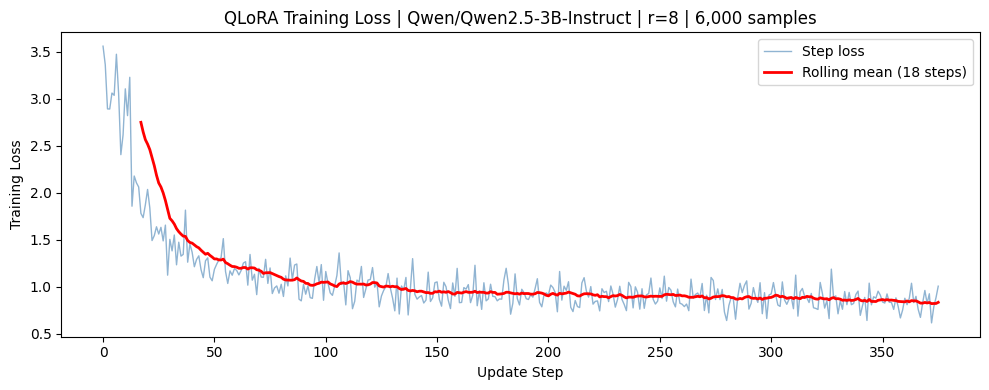

Loss curve saved: /content/qlora_qwen_customer_support/training_loss.png


In [15]:
import matplotlib.pyplot as plt

if loss_history:
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(loss_history, lw=1.0, color='steelblue', alpha=0.6, label='Step loss')
    window  = max(1, len(loss_history) // 20)
    rolling = np.convolve(loss_history, np.ones(window)/window, mode='valid')
    ax.plot(range(window - 1, len(loss_history)), rolling,
            color='red', lw=2.0, label=f'Rolling mean ({window} steps)')
    ax.set_xlabel('Update Step')
    ax.set_ylabel('Training Loss')
    ax.set_title(
        f'QLoRA Training Loss | {MODEL_NAME} | r={CFG["lora"]["r"]} | {TRAIN_N:,} samples'
    )
    ax.legend()
    plt.tight_layout()
    plot_path = os.path.join(OUTPUT_DIR, 'training_loss.png')
    plt.savefig(plot_path, dpi=150)
    plt.show()
    print(f'Loss curve saved: {plot_path}')
else:
    print('No loss history.')

## 16. Save LoRA Adapter

In [16]:
ADAPTER_DIR = os.path.join(OUTPUT_DIR, 'lora_adapter')
Path(ADAPTER_DIR).mkdir(parents=True, exist_ok=True)

unwrapped = accelerator.unwrap_model(trained_model)
unwrapped.save_pretrained(ADAPTER_DIR)
tokenizer.save_pretrained(ADAPTER_DIR)

print(f'LoRA adapter saved to: {ADAPTER_DIR}')
for p in sorted(Path(ADAPTER_DIR).iterdir()):
    print(f'  {p.name}  ({p.stat().st_size / 1e6:.1f} MB)')

LoRA adapter saved to: /content/qlora_qwen_customer_support/lora_adapter
  README.md  (0.0 MB)
  adapter_config.json  (0.0 MB)
  adapter_model.safetensors  (7.4 MB)
  chat_template.jinja  (0.0 MB)
  tokenizer.json  (11.4 MB)
  tokenizer_config.json  (0.0 MB)


In [21]:
import shutil
import os

# 1. Define the path of the folder you want to zip
folder_to_zip = '/content/qlora_qwen_customer_support/best_checkpoint'  # Replace with your target folder path

# 2. Define the output path and filename (without the .zip extension)
# Saving to /content as requested
output_filename = '/content/download_bestcheckpoin'

# 3. Create the zip archive
shutil.make_archive(output_filename, 'zip', folder_to_zip)

print(f"Successfully zipped! You can find it at: {output_filename}.zip")

Successfully zipped! You can find it at: /content/download_bestcheckpoin.zip


In [22]:
!ls -lh /content/download_bestcheckpoin.zip

-rw-r--r-- 1 root root 6.6M Apr  4 19:51 /content/download_bestcheckpoin.zip


## 17. (Optional) Merge LoRA Weights into Base Model
Produces a standalone model with no PEFT dependency — easier to run inference or push to HuggingFace Hub.  
The merge is done on CPU to avoid VRAM limits. Skip if you only need the adapter.

In [17]:
MERGE      = CFG.get('inference', {}).get('merge_weights', False)
MERGED_DIR = CFG.get('inference', {}).get('merged_output_dir', os.path.join(CFG['checkpointing']['output_dir'], 'merged_model'))

if MERGE:
    print('Merging LoRA weights into base model on CPU...')
    base = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME,
        torch_dtype=torch.float16,
        device_map='cpu',
        trust_remote_code=True,
    )
    merged = PeftModel.from_pretrained(base, ADAPTER_DIR)
    merged = merged.merge_and_unload()
    Path(MERGED_DIR).mkdir(parents=True, exist_ok=True)
    merged.save_pretrained(MERGED_DIR, safe_serialization=True)
    tokenizer.save_pretrained(MERGED_DIR)
    print(f'Merged model saved: {MERGED_DIR}')
    del merged, base
    gc.collect()
else:
    print('Merge skipped (merge_weights=false in config or missing).')

Merge skipped (merge_weights=false in config or missing).


## 18. End MLflow Run & Summary

In [18]:
accelerator.end_training()

print()
print('=' * 55)
print('TRAINING COMPLETE — SUMMARY')
print('=' * 55)
print(f'Model            : {MODEL_NAME}')
print(f'Train samples    : {TRAIN_N:,}')
print(f'Epochs           : {NUM_EPOCHS}')
print(f'LoRA r / alpha   : {CFG["lora"]["r"]} / {CFG["lora"]["lora_alpha"]}')
print(f'Target modules   : {CFG["lora"]["target_modules"]}')
print(f'Optimizer        : bitsandbytes AdamW 8-bit')
print(f'Pre-train PPL    : {pre_ppl:.4f}')
print(f'Post-train PPL   : {post_ppl:.4f}  (delta={delta:+.4f})')
print(f'Adapter saved    : {ADAPTER_DIR}')
print(f'MLflow run       : {CFG["mlflow"]["experiment_name"]}')
print(f'Output dir       : {OUTPUT_DIR}')

🏃 View run qlora_r8_1epoch_6k at: https://dagshub.com/nemroneno2526/LLM_project.mlflow/#/experiments/0/runs/0a9f3de130f9412bad81df3f83891435
🧪 View experiment at: https://dagshub.com/nemroneno2526/LLM_project.mlflow/#/experiments/0

TRAINING COMPLETE — SUMMARY
Model            : Qwen/Qwen2.5-3B-Instruct
Train samples    : 6,000
Epochs           : 1
LoRA r / alpha   : 8 / 16
Target modules   : ['q_proj', 'v_proj']
Optimizer        : bitsandbytes AdamW 8-bit
Pre-train PPL    : 24.6757
Post-train PPL   : 2.4071  (delta=-22.2686)
Adapter saved    : /content/qlora_qwen_customer_support/lora_adapter
MLflow run       : qwen25_3b_qlora_banking_conversation
Output dir       : /content/qlora_qwen_customer_support
